In [65]:
import numpy as np

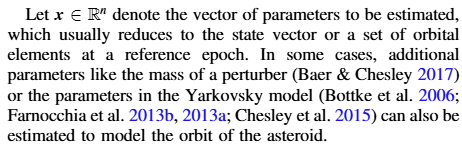

In [66]:
import requests

response = requests.get("https://data.minorplanetcenter.net/api/get-orb", json={"desig": "Eros"})

if response.ok:
    orb = response.json()[0]['mpc_orb']
else:
    print("Error: ", response.status_code, response.content)

In [67]:
print(orb[0].keys())
print(orb[0]['CAR'].keys())
print(orb[0]['COM'].keys())
print(orb[0]['categorization'].keys())
print(orb[0]['designation_data'].keys())
print(orb[0]['designation_data'].keys())
print(orb[0]['epoch_data'].keys())
print(orb[0]['magnitude_data'].keys())
print(orb[0]['moid_data'].keys())
print(orb[0]['non_grav_booleans'].keys())
print(orb[0]['orbit_fit_statistics'].keys())
print(orb[0]['software_data'].keys())
print(orb[0]['system_data'].keys())

dict_keys(['CAR', 'COM', 'categorization', 'designation_data', 'epoch_data', 'magnitude_data', 'moid_data', 'non_grav_booleans', 'orbit_fit_statistics', 'software_data', 'system_data'])
dict_keys(['coefficient_names', 'coefficient_uncertainties', 'coefficient_values', 'covariance', 'eigenvalues'])
dict_keys(['coefficient_names', 'coefficient_uncertainties', 'coefficient_values', 'covariance', 'eigenvalues'])
dict_keys(['object_type_int', 'object_type_str', 'orbit_subtype_int', 'orbit_subtype_str', 'orbit_type_int', 'orbit_type_str'])
dict_keys(['designation_count', 'iau_name', 'name', 'new_style_packed_secondary_provisional_designations', 'orbfit_name', 'packed_primary_provisional_designation', 'packed_secondary_provisional_designations', 'permid', 'unpacked_primary_provisional_designation', 'unpacked_secondary_provisional_designations'])
dict_keys(['designation_count', 'iau_name', 'name', 'new_style_packed_secondary_provisional_designations', 'orbfit_name', 'packed_primary_provisional

In [68]:
print(orb[0]['system_data']['refframe'])
print(orb[0]['system_data']['refsys'])

ICRF
Ecliptic


In [69]:
orbital_elements = orb[0]['CAR']['coefficient_values']
x = np.array(orbital_elements)

In [70]:
AU_to_km = 1.495978707e8
day_to_sec = 86400.0

In [71]:
x[:3] *= AU_to_km
x[3:] *= AU_to_km / day_to_sec

In [72]:
print(x)

[ 1.20144699e+08  1.48565328e+08  3.49924625e+07 -2.41244768e+01
  1.30481711e+01 -2.40794861e+00]


In [73]:
t0_mjd = orb[0]['epoch_data']['epoch']

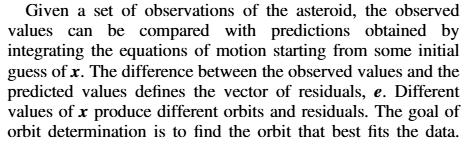

In [74]:
import spiceypy as sp

# The meta kernel file contains entries pointing to the following SPICE kernels, which the user needs to download.
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440s.bsp
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_000101_260619_260323.bpc
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_latest_high_prec.bpc

#   The following is the contents of a metakernel that was saved with
#   the name 'cassMetaK.txt'.
#   \begindata
#   KERNELS_TO_LOAD=(
#     'naif0012.tls',
#     'de440s.bsp',
#     'earth_000101_260619_260323.bpc',
#     'earth_latest_high_prec.bpc',
#   )
#   \begintext

sp.furnsh("./planetaryMetaK.txt")

In [75]:
help(sp.spkezr)

Help on function spkezr in module spiceypy.spiceypy:

spkezr(targ: str, et: Union[ndarray, float], ref: str, abcorr: str, obs: str) -> Union[Tuple[ndarray, float], Tuple[Iterable[ndarray], Iterable[float]]]
    Return the state (position and velocity) of a target body
    relative to an observing body, optionally corrected for light
    time (planetary aberration) and stellar aberration.

    https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/spkezr_c.html

    :param targ: Target body name.
    :param et: Observer epoch in seconds past J2000 TDB.
    :param ref: Reference frame of output state vector.
    :param abcorr: Aberration correction flag.
    :param obs: Observing body name.
    :return:
            State of target in km and km/sec,
            One way light time between observer and target in seconds.



In [76]:
sun_radius = 695700 #km
sun_mu = 1.32712440018e11  # km^3/s^2

In [77]:
def two_body_ode(t, state):
    
    '''
    Newtons Universal Law of Gravitation
    '''
    
    r = state[:3]
    v = state[3:]
    r_norm = np.linalg.norm(r)
    a = -sun_mu * r / r_norm**3
    
    return np.concatenate((v, a))

In [78]:
from scipy.integrate import solve_ivp

In [79]:
help(solve_ivp)

Help on function solve_ivp in module scipy.integrate._ivp.ivp:

solve_ivp(
    fun,
    t_span,
    y0,
    method='RK45',
    t_eval=None,
    dense_output=False,
    events=None,
    vectorized=False,
    args=None,
    **options
)
    Solve an initial value problem for a system of ODEs.

    This function numerically integrates a system of ordinary differential
    equations given an initial value::

        dy / dt = f(t, y)
        y(t0) = y0

    Here t is a 1-D independent variable (time), y(t) is an
    N-D vector-valued function (state), and an N-D
    vector-valued function f(t, y) determines the differential equations.
    The goal is to find y(t) approximately satisfying the differential
    equations, given an initial value y(t0)=y0.

    Some of the solvers support integration in the complex domain, but note
    that for stiff ODE solvers, the right-hand side must be
    complex-differentiable (satisfy Cauchy-Riemann equations [11]_).
    To solve a problem in the complex

In [80]:
def propagate(x, t0, ti):
    sol = solve_ivp(
        two_body_ode,
        (t0, ti),
        x,
        method = "DOP853",
        rtol=1e-12,
        atol=1e-12
    )
    
    return sol.y[:, -1]

In [81]:
response = requests.get("https://data.minorplanetcenter.net/api/get-obs", json={"desigs": ["Eros"], "output_format": ["ADES_DF"]})

if response.ok:
    obs_data = response.json()[0]['ADES_DF']
else:
    print("Error: ", response.status_code, response.content)


In [82]:
print(obs_data[0].keys())

dict_keys(['Obstype', 'artsat', 'astcat', 'band', 'com', 'ctr', 'dec', 'decstar', 'delay', 'deltadec', 'deltara', 'deprecated', 'disc', 'dist', 'doppler', 'exp', 'fltr', 'frq', 'localuse', 'logsnr', 'mag', 'mode', 'notes', 'nstars', 'nucmag', 'obscenter', 'obsid', 'obssubid', 'obstime', 'pa', 'permid', 'photap', 'photcat', 'pos1', 'pos2', 'pos3', 'poscov11', 'poscov12', 'poscov13', 'poscov22', 'poscov23', 'poscov33', 'precdec', 'precra', 'prectime', 'prog', 'provid', 'ra', 'rastar', 'rcv', 'ref', 'remarks', 'rmscorr', 'rmsdec', 'rmsdelay', 'rmsdist', 'rmsdoppler', 'rmsfit', 'rmsmag', 'rmspa', 'rmsra', 'rmstime', 'seeing', 'shapeocc', 'stn', 'subfmt', 'subfrm', 'sys', 'trkid', 'trkmpc', 'trksub', 'trx', 'unctime', 'vel1', 'vel2', 'vel3'])


In [83]:
for n, obs in enumerate(obs_data):
    obs['obstime'] = sp.str2et(obs['obstime'])
    obs_data[n] = obs

In [84]:
print(obs_data[0]['obstime'])
print(obs_data[1]['obstime'])

print(obs_data[-1]['stn'])

-3350513058.337489
-3350346081.6974645
C23


In [85]:
def angle_diff(a, b):
    return (a - b + np.pi) % (2*np.pi) - np.pi

In [86]:
t_epoch = sp.unitim(t0_mjd + 2400000.5, 'JDTDB', 'ET')  # MJD 61000 ≈ this date

for n, obs in enumerate(obs_data):
    if obs['obstime'] >= t_epoch:
        obs_index = n
        break
    
t0 = obs_data[obs_index]['obstime']
    
print(f"Propagating from {obs_index}th observation at {t0}")

Propagating from 16810th observation at 817011380.798867


In [87]:
x = propagate(x, 0.0, t0 - t_epoch)

In [88]:
R_earth = 6378.137 #km

In [89]:
ecl_to_j2000 = sp.pxform('ECLIPJ2000', 'J2000', t0)
x = np.concatenate([ecl_to_j2000 @ x[:3], ecl_to_j2000 @ x[3:]])

In [90]:
# stations.csv downloaded from https://www.minorplanetcenter.net/iau/lists/ObsCodes.html

import csv

def get_stn_properties(stn):
    
    with open('stations.csv', 'r', newline='\n') as stns:
        reader = csv.DictReader(stns)
        for row in reader:
            if row['Code'] == stn:
                return {
                    'Long.': float(row['Long.']) if row['Long.'].strip() != '' else None,
                    'cos': float(row['cos']) if row['cos'].strip() != '' else None,
                    'sin': float(row['sin']) if row['sin'].strip() != '' else None,
                }
    return None

In [91]:
def stn_to_ecef(stn, properties):
    
    lon = np.deg2rad(properties['Long.'])
    x = R_earth * properties['cos'] * np.cos(lon)
    y = R_earth * properties['cos'] * np.sin(lon)
    z = R_earth * properties['sin']
    
    return np.array([x, y, z])
    
            

In [92]:
help(sp.pxform)

Help on function pxform in module spiceypy.spiceypy:

pxform(fromstr: str, tostr: str, et: float) -> ndarray
    Return the matrix that transforms position vectors from one
    specified frame to another at a specified epoch.

    https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/pxform_c.html

    :param fromstr: Name of the frame to transform from.
    :param tostr: Name of the frame to transform to.
    :param et: Epoch of the rotation matrix.
    :return: A rotation matrix.



In [93]:
def get_observer_pos_j2000(stn, t_obs, properties):
    
    r_ecef = stn_to_ecef(stn, properties)
    
    earth, _ = sp.spkezr('EARTH', t_obs, 'J2000', 'NONE', 'SUN')
    rot = sp.pxform('ITRF93', 'J2000', t_obs)
    r_obs_j2000 = rot @ r_ecef
    
    return earth[:3] + r_obs_j2000

In [94]:
c_km_s = 299792.458

In [95]:
from collections import Counter

print(Counter(obs.get('astcat') for obs in obs_data[obs_index:]))
print(Counter(obs.get('mode') for obs in obs_data[obs_index:]))
print(Counter(obs.get('stn') for obs in obs_data[obs_index:]))

Counter({'Gaia2': 582, 'Gaia3E': 459, 'ATLAS2': 70, 'UCAC4': 26, 'USNOA2': 20, 'Gaia3': 14})
Counter({'CCD': 1037, 'CMO': 134})
Counter({'270': 488, 'C40': 380, 'C23': 49, 'L65': 24, 'L76': 22, '233': 20, '703': 20, 'J51': 18, '006': 17, '160': 17, 'D29': 15, 'D04': 12, '122': 9, 'X33': 9, 'G96': 8, 'K74': 6, 'G17': 6, 'R61': 6, 'M22': 5, 'T08': 4, 'G11': 3, 'M59': 3, 'X76': 3, 'Y84': 3, 'M73': 3, 'G02': 3, 'X04': 3, 'K87': 3, 'R97': 3, '185': 3, 'T05': 3, 'L92': 3})


In [96]:
print(obs_data[obs_index+13]['rmsra'], obs_data[obs_index+13]['rmsdec']) # both are str


0.09 0.19


In [97]:
VFCCLookup = {
# (stn, astcat) : (ra, dec) arcsec 

# USNOA2.0 
('704', 'USNOA2')  : (0.63, 0.60),
('699', 'USNOA2')  : (0.62, 0.53),
('691', 'USNOA2')  : (0.30, 0.30),
('608', 'USNOA2')  : (0.61, 0.75),
('703', 'USNOA2')  : (0.69, 0.63),
('644', 'USNOA2')  : (0.29, 0.30),
('291', 'USNOA2')  : (0.46, 0.32),
('599', 'USNOA2')  : (0.39, 0.34),
('333', 'USNOA2')  : (0.55, 0.53),
('D35', 'USNOA2')  : (0.39, 0.38),

# USNOA1.0 
('704', 'USNOA1')  : (0.76, 0.73),
('691', 'USNOA1')  : (0.49, 0.46),

# USNOB1.0 
('699', 'USNOB1')  : (0.61, 0.54),
('644', 'USNOB1')  : (0.24, 0.20),
('691', 'USNOB1')  : (0.30, 0.28),
('291', 'USNOB1')  : (0.39, 0.26),

# UCAC1
('703', 'UCAC1')   : (0.63, 0.59),
('G96', 'UCAC1')   : (0.32, 0.27),
('E12', 'UCAC1')   : (0.50, 0.45),
('683', 'UCAC1')   : (0.79, 0.90),
('J75', 'UCAC1')   : (0.41, 0.37),
('106', 'UCAC1')   : (0.40, 0.39),
('143', 'UCAC1')   : (0.57, 0.47),

# UCAC2
('703', 'UCAC2')   : (0.63, 0.59),
('G96', 'UCAC2')   : (0.32, 0.27),
('E12', 'UCAC2')   : (0.50, 0.45),
('683', 'UCAC2')   : (0.79, 0.90),
('J75', 'UCAC2')   : (0.41, 0.37),
('106', 'UCAC2')   : (0.40, 0.39),
('143', 'UCAC2')   : (0.57, 0.47),

# Gaia2
('T14', 'Gaia2')   : (0.10, 0.10),
('T12', 'Gaia2')   : (0.10, 0.10),
('T09', 'Gaia2')   : (0.10, 0.10),
('Y28', 'Gaia2')   : (0.30, 0.30),
('568', 'Gaia2')   : (0.10, 0.10),
('G83', 'Gaia2')   : (0.20, 0.20),
('309', 'Gaia2')   : (0.20, 0.20),

# Gaia3
('T14', 'Gaia3')   : (0.10, 0.10),
('T12', 'Gaia3')   : (0.10, 0.10),
('T09', 'Gaia3')   : (0.10, 0.10),
('Y28', 'Gaia3')   : (0.30, 0.30),
('568', 'Gaia3')   : (0.10, 0.10),
('G83', 'Gaia3')   : (0.20, 0.20),
('309', 'Gaia3')   : (0.20, 0.20),

# Gaia3E
('T14', 'Gaia3E')  : (0.10, 0.10),
('T12', 'Gaia3E')  : (0.10, 0.10),
('T09', 'Gaia3E')  : (0.10, 0.10),
('Y28', 'Gaia3E')  : (0.30, 0.30),
('568', 'Gaia3E')  : (0.10, 0.10),
('G83', 'Gaia3E')  : (0.20, 0.20),
('309', 'Gaia3E')  : (0.20, 0.20),

# Tycho-2
('689', 'Tycho-2') : (0.20, 0.21),

}

VFCCAstcat = {
# (astcat) : (ra, dec) arcsec 

'Tycho-2'          : (0.24, 0.25),
'UCAC2'            : (0.53, 0.49),
'UCAC1'            : (0.53, 0.49),
'UCAC4'            : (0.30, 0.30),
'USNOB1'           : (0.48, 0.42),
'USNOA1'           : (0.72, 0.69),
'USNOA2'           : (0.61, 0.58),
'Gaia2'            : (0.20, 0.20),
'Gaia3'            : (0.20, 0.20),
'Gaia3E'           : (0.20, 0.20),
'ATLAS2'           : (0.20, 0.20),

}

VFCCStn = {
# (stn) : (ra, dec) arcsec 

'645'              : (0.30, 0.30),
'673'              : (0.30, 0.30),
'689'              : (0.50, 0.50),
'950'              : (0.50, 0.50),
'H01'              : (0.30, 0.30),
'J04'              : (0.40, 0.40),
'W84'              : (0.50, 0.50),
'LCO'              : (0.40, 0.40),

}

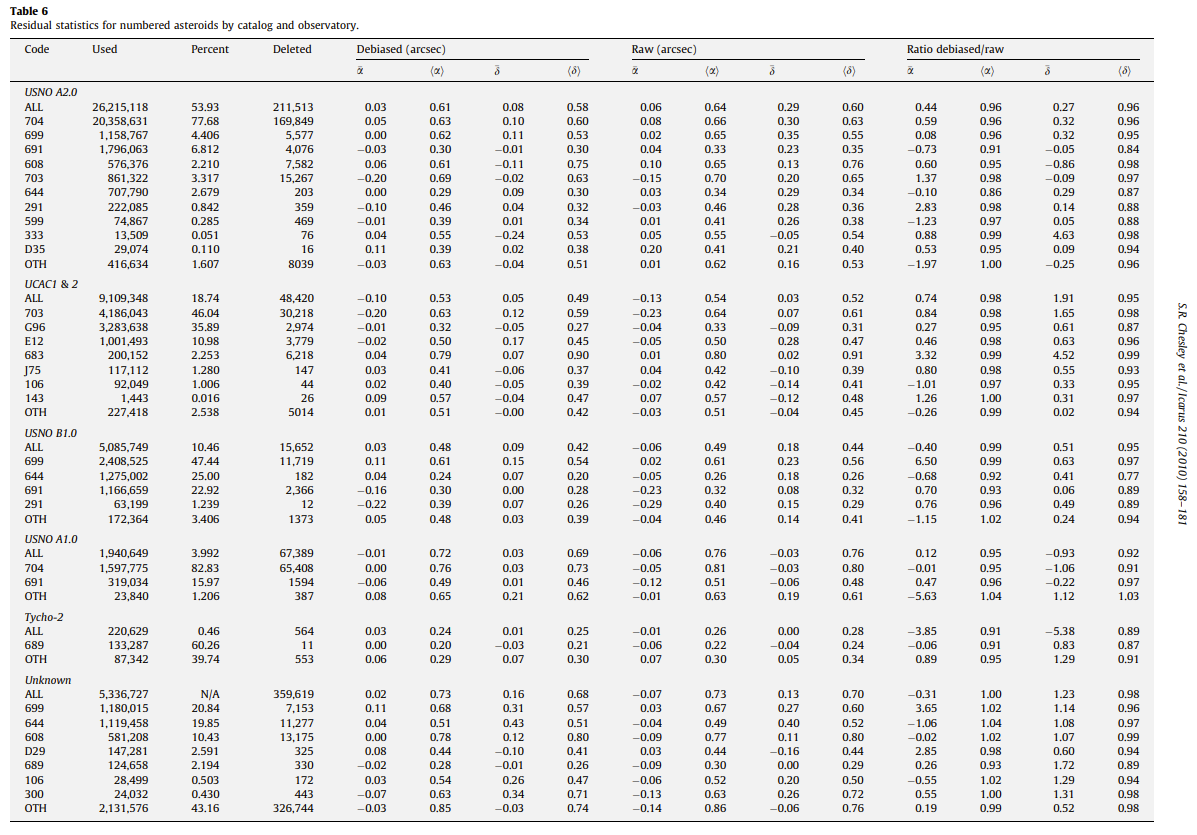

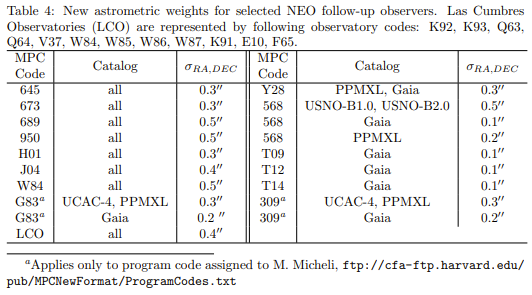

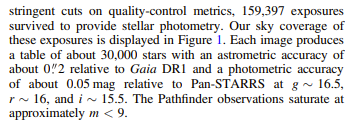

In [98]:
arcsec_to_rad = np.deg2rad(1/3600)

In [99]:
def astrometric_error(details, dec_obs):
    
    sigma_ra  = None
    sigma_dec = None
    
    def rms(sigma_ra, sigma_dec):
        
        return {
            "rmsra" : 1 / sigma_ra ** 2,
            "rmsdec" : 1 / sigma_dec ** 2}
    
    if details["rmsra"] is not None and details["rmsdec"] is not None:
        
        sigma_ra  = float(details["rmsra"])
        sigma_dec = float(details["rmsdec"])
        
    elif (details["stn"], details["astcat"]) in VFCCLookup:
        
        sigma_ra  = VFCCLookup[(details["stn"], details["astcat"])][0] * np.cos(dec_obs)
        sigma_dec = VFCCLookup[(details["stn"], details["astcat"])][1]
        
    elif details["stn"] in VFCCStn and details["astcat"] in VFCCAstcat:
        
        sigma_ra  = VFCCAstcat[details["astcat"]][0] * np.cos(dec_obs)
        sigma_dec = VFCCAstcat[details["astcat"]][1]
        
        if sigma_ra < VFCCStn[details["stn"]][0]:
            sigma_ra = VFCCStn[details["stn"]][0] * np.cos(dec_obs)
            
        if sigma_dec < VFCCStn[details["stn"]][1]:
            sigma_dec = VFCCStn[details["stn"]][1]
        
    elif details["astcat"] in VFCCAstcat:
        
        sigma_ra  = VFCCAstcat[details["astcat"]][0] * np.cos(dec_obs)
        sigma_dec = VFCCAstcat[details["astcat"]][1]
        
    elif details["stn"] in VFCCStn:
        
        sigma_ra  = VFCCStn[details["stn"]][0] * np.cos(dec_obs)
        sigma_dec = VFCCStn[details["stn"]][1]
        
    else:
        
        sigma_arcsec = 0.2 # estimate
        sigma = sigma_arcsec * arcsec_to_rad
        
        sigma_ra  = sigma * np.cos(dec_obs)
        sigma_dec = sigma
        
    sigma_ra_rad  = sigma_ra * arcsec_to_rad
    sigma_dec_rad = sigma_ra * arcsec_to_rad
        
    rms_values = rms(sigma_ra=sigma_ra_rad, sigma_dec=sigma_dec_rad)
    
    return [rms_values["rmsra"], rms_values["rmsdec"]]

In [100]:
residual_states = []
weights = []

for obs in obs_data[obs_index:]:
    
    t_obs   = obs['obstime']
    ra_obs  = np.deg2rad(float(obs['ra']))
    dec_obs = np.deg2rad(float(obs['dec']))
        
    dt = t_obs - t0
    eros = propagate(x, 0.0, dt)
    
    stn    = obs['stn']
    astcat = obs['astcat']
    
    stn_properties = get_stn_properties(stn)
    
    if stn_properties['sin'] == None and stn_properties['cos'] == None:
        earth, _ = sp.spkezr('EARTH', t_obs, 'J2000', 'NONE', 'SUN')
        obs_pos = earth[:3]
    else:
        obs_pos = get_observer_pos_j2000(stn, t_obs, stn_properties)
        
    for _ in range(3):
        
        rho = eros[:3] - obs_pos
        lt = np.linalg.norm(rho) / c_km_s
        
        eros = propagate(x, 0.0, dt - lt)
    
    rho = eros[:3] - obs_pos
    rho_hat = rho / np.linalg.norm(rho)
    
    ra_pred = np.arctan2(rho_hat[1], rho_hat[0])
    ra_pred = np.mod(ra_pred, 2*np.pi)
    
    dec_pred = np.arcsin(rho_hat[2])
    
    residual = [angle_diff(ra_obs, ra_pred), dec_obs - dec_pred]
    
    residual_states.append(residual)
    
    rmsra = obs['rmsra']
    rmsdec = obs['rmsdec']
    
    telescope_details = {"stn": stn, "astcat": astcat, "rmsra": rmsra, "rmsdec": rmsdec}
    
    weight = astrometric_error(telescope_details, dec_obs)
    
    weights.append(weight)
    
residual_states = np.array(residual_states)
weights = np.array(weights)
    
print(residual_states[:3])

[[ 4.44024256e-07 -2.00615998e-07]
 [ 2.38215268e-07  1.02645807e-07]
 [ 1.80996067e-07 -1.59544381e-07]]


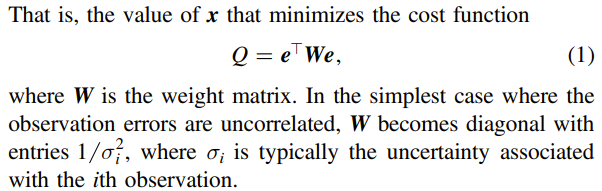

In [101]:
e = residual_states.flatten().reshape(-1, 1) # 2*sum(obs_index:), 1
e_t = e.T # 1, 2*sum(obs_index:)

W = np.diag(weights.flatten()) # 2*sum(obs_index:), 2*sum(obs_index:)

q = e_t @ W @ e #1, 1

Q = float(q[0, 0])

print(Q)

21989826.290670123


## Tests

In [103]:
print(np.mean(np.abs(residual_states)) / arcsec_to_rad)

5.546335252158657


In [105]:
cont = (e.flatten()**2) * weights.flatten()
top_idx = np.argsort(cont)[-10:]
for i in top_idx:
    obs_i = i // 2
    print(
        obs_data[obs_index + obs_i]['stn'],
        obs_data[obs_index + obs_i]['astcat'],
        obs_data[obs_index + obs_i]['rmsra'],
        obs_data[obs_index + obs_i]['rmsdec'],
    )

D29 Gaia2 0.008 0.007
D29 Gaia2 0.011 0.009
D29 Gaia2 0.010 0.009
D29 Gaia2 0.010 0.009
D29 Gaia2 0.009 0.008
D29 Gaia2 0.008 0.006
D29 Gaia2 0.008 0.007
D29 Gaia2 0.007 0.007
D29 Gaia2 0.007 0.006
D29 Gaia2 0.007 0.006
